### Testing custom TTF transformations
This notebook can be used to visualize the different (custom) versions of the TTF transformation.

In [1]:
from typing import Union
import numpy as np

# ML modules
import torch

# visualization
import matplotlib.pyplot as plt

# To avoid meshgrid warning
import warnings
warnings.filterwarnings("ignore", category=UserWarning, module='torch')

# local modules
from tailnflows.models.extreme_transformations import TailAffineMarginalTransform, ModifiedTailAffineMarginalTransform
from tailnflows.models.tail_estimation import estimate_df

### Plot the 1d Transformation

In [2]:
def plot_transform(transforms: list[Union[TailAffineMarginalTransform, ModifiedTailAffineMarginalTransform]], x_low: float = -5.0, x_high: float = 5.0, num_points: int = 1000):
    """
    Plot the forward and inverse transformations along with their lads.
    
    Args:
        transform (TailAffineMarginalTransform): The transformation to plot.
        x_low (float): The lower bound of the domain on which to plot.
        x_high (float): The upper bound of the domain on which to plot.
        num_points (int): The number of points to plot.
    """
    x = np.linspace(x_low, x_high, num_points)

    fig, axs = plt.subplots(2, 2, figsize=(12, 6))

    for i, transform in enumerate(transforms):
        x_tensor = torch.from_numpy(x).to('cpu').float().unsqueeze(-1)
        y_fwd, lad_fwd = transform.forward(x_tensor)
        y_fwd = y_fwd.detach().numpy()
        lad_fwd = lad_fwd.detach().numpy()
        y_back, lad_back = transform.inverse(x_tensor)
        y_back = y_back.detach().numpy()
        lad_back = lad_back.detach().numpy()

        if i == 0:
            axs[0, 0].plot(x, y_fwd, 'b-', label='Transform 1')
            axs[0, 1].plot(x, lad_fwd, 'b-', label='Transform 1')
            axs[1, 0].plot(x, y_back, 'b-', label='Transform 1')
            axs[1, 1].plot(x, lad_back, 'b-', label='Transform 1')

        else:
            axs[0, 0].plot(x, y_fwd, 'r:', label=f'Transform {i+1}')
            axs[0, 1].plot(x, lad_fwd, 'r:', label=f'Transform {i+1}')
            axs[1, 0].plot(x, y_back, 'r:', label=f'Transform {i+1}')
            axs[1, 1].plot(x, lad_back, 'r:', label=f'Transform {i+1}')

    axs[0, 0].set_title('Forward Transformation')
    axs[0, 0].grid()
    axs[0, 0].set_xlim(x_low, x_high)
    axs[0, 1].set_title('Forward Transformation Lad')
    axs[0, 1].grid()
    axs[0, 1].set_xlim(x_low, x_high)
    axs[1, 0].set_title('Inverse Transformation')
    axs[1, 0].grid()
    axs[1, 0].set_xlim(x_low, x_high)
    axs[1, 1].set_title('Inverse Transformation Lad')
    axs[1, 1].grid()
    axs[1, 1].set_xlim(x_low, x_high)

    axs[0, 0].legend()
    axs[0, 1].legend()
    axs[1, 0].legend()
    axs[1, 1].legend()

    fig.tight_layout()
    fig.show()

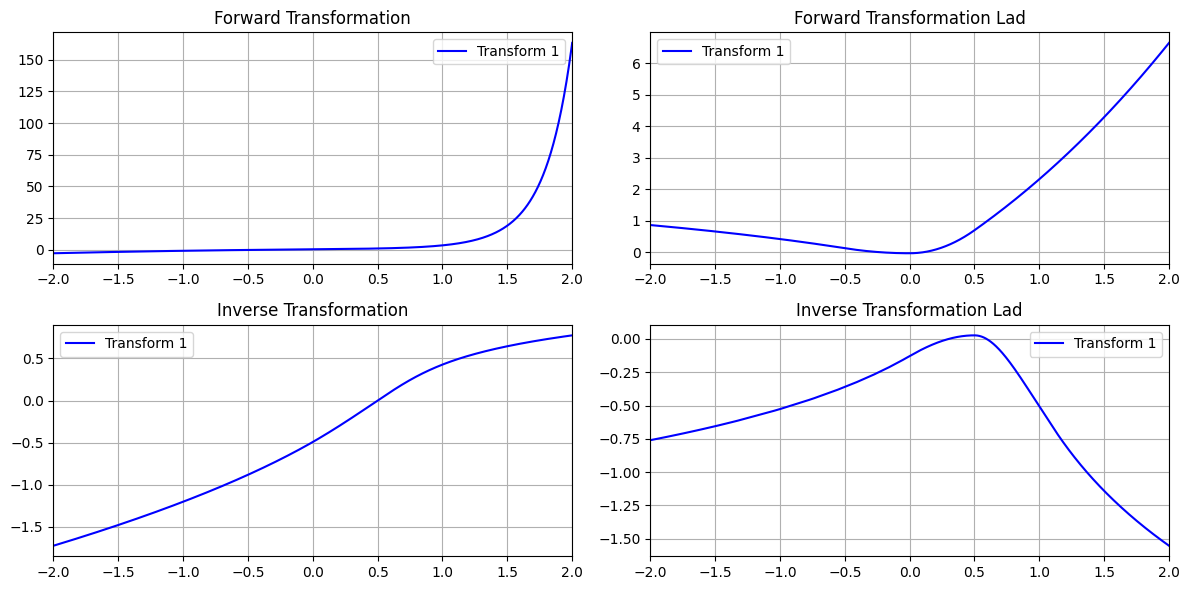

In [3]:
lam_pos = 2.0
lam_neg = 0.001
shift = 0.5
scale = 1.0
hd_only = False
mod = "erfi"
a_pos = 0.5
a_neg = -0.5

x_low = -2.0
x_high = 2.0

trafo = ModifiedTailAffineMarginalTransform(
    features=1,
    pos_tail_init=torch.tensor([lam_pos]),
    neg_tail_init=torch.tensor([lam_neg]),
    shift_init=torch.tensor([shift]),
    scale_init=torch.tensor([scale]),
    fix=False,
    hd_only=hd_only,
    mod=mod,
    a_pos=torch.tensor([a_pos]) if a_pos is not None else None,
    a_neg=torch.tensor([a_neg]) if a_neg is not None else None,
)

transforms = [trafo]

plot_transform(transforms, x_low, x_high)